In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import ast
import warnings
import json
warnings.filterwarnings("ignore")

from raiwidgets import ExplanationDashboard
from interpret.ext.blackbox import TabularExplainer
from responsibleai import RAIInsights
from raiwidgets import ResponsibleAIDashboard

In [26]:
path_data = '/Users/monicaromero/PycharmProjects/afasia_cat/notebooks_202412/data/'
df_catalan = pd.read_csv(path_data + 'df_transcrip_audio_metrics.csv', encoding='utf-8')

df_aphbank = pd.read_csv(path_data + 'df_aphasiabank_metrics.csv', encoding='utf-8')

In [27]:
def process_bert_embedding(df):
    """
    Función para procesar la columna 'bert_embedding' en un DataFrame.
    Detecta si 'bert_embedding' ya es una lista o si necesita conversión desde string.
    """
    if "bert_embedding" not in df.columns:
        print("Advertencia: 'bert_embedding' no está en el DataFrame.")
        return df

    # Verificar el tipo de datos en bert_embedding
    sample_value = df["bert_embedding"].dropna().iloc[0] if not df["bert_embedding"].dropna().empty else None

    # Si bert_embedding está en formato string, lo convertimos
    def convert_to_list(value):
        if isinstance(value, str):
            try:
                return json.loads(value)  # Usa JSON en vez de ast.literal_eval para mayor seguridad
            except json.JSONDecodeError:
                try:
                    return ast.literal_eval(value)
                except (ValueError, SyntaxError):
                    return None
        elif isinstance(value, (list, np.ndarray)):  
            return list(value)  # Si ya es lista o array, mantenerlo igual
        return None

    # Aplicar conversión solo si es necesario
    if isinstance(sample_value, str):  # Si detecta strings, aplica conversión
        df["bert_embedding"] = df["bert_embedding"].apply(convert_to_list)

    # Eliminar filas con valores no válidos en 'bert_embedding'
    df = df[df["bert_embedding"].notnull()]

    # Expandir 'bert_embedding' en columnas individuales
    bert_columns = [f'bert_{i}' for i in range(len(df["bert_embedding"].iloc[0]))]
    bert_df = pd.DataFrame(df["bert_embedding"].tolist(), columns=bert_columns)

    # Concatenar las nuevas columnas con el DataFrame original
    df = pd.concat([df.drop(columns=["bert_embedding"]), bert_df], axis=1)

    return df


df_catalan = process_bert_embedding(df_catalan)
df_aphbank = process_bert_embedding(df_aphbank)

df_aphbank = df_aphbank.reindex(columns=df_catalan.columns, fill_value=np.nan)
df = pd.concat([df_catalan, df_aphbank], ignore_index=True)

In [28]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

NumId                 813
TipusAfàsia           460
Fluente/No Fluente    460
dtype: int64

In [29]:
df['CIP'].unique()

array(['02_008', '02_007', '02_002', '02_003', '01_003', '01_005',
       '01_007', '01_001', '01_004', 'TCU06a', 'TCU04a', 'TCU02a',
       'TCU10a'], dtype=object)

In [30]:
df[df['Fluente/No Fluente'].isna()]['CIP'].unique() # TODO: no tenemos en cuenta estos dos por tipo de afasia pero si los tendriamos en caso de clasificar por WAB_QA

array(['TCU06a', 'TCU10a'], dtype=object)

In [31]:
df = df.dropna(subset=['Fluente/No Fluente'])

In [32]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

NumId    353
dtype: int64

In [33]:
df.columns

Index(['Inicio', 'Fin', 'Marca', 'Transcrip_name', 'Duración',
       'name_chunk_audio', 'name_chunk_audio_path', 'CIP', 'NumId', 'Gènere',
       ...
       'bert_758', 'bert_759', 'bert_760', 'bert_761', 'bert_762', 'bert_763',
       'bert_764', 'bert_765', 'bert_766', 'bert_767'],
      dtype='object', length=905)

In [34]:
# Seleccionar características (X) y la variable objetivo (y)
irrelevant_columns = ['Inicio', 'Fin', 'Transcrip_name', 'name_chunk_audio', 'name_chunk_audio_path', 'NumId', 'TipusAfàsia'] #quito tambien TipusAfàsia porque clasificaria solo con ella 
X = df.drop(columns=irrelevant_columns + ['Fluente/No Fluente']) 
X = X.select_dtypes(include=['number'])  # Asegurarse de que solo queden columnas numéricas
y = df['Fluente/No Fluente']

In [35]:
# Dividir los datos respetando los grupos de pacientes
groups = df["CIP"]  # Columna que identifica a cada paciente
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx] 

In [36]:
df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

In [37]:
print("Tamaño del conjunto de entrenamiento:", df_train.shape)
print("Tamaño del conjunto de test:", df_test.shape)

Tamaño del conjunto de entrenamiento: (488, 905)
Tamaño del conjunto de test: (408, 905)


In [38]:
print("Pacientes en entrenamiento:", df_train["CIP"].unique())
print("Pacientes en test:", df_test["CIP"].unique())

Pacientes en entrenamiento: ['02_008' '02_007' '02_003' '01_003' '01_005' '01_007' '01_004']
Pacientes en test: ['02_002' '01_001' 'TCU04a' 'TCU02a']


In [39]:
print("Distribución de 'Grup' en entrenamiento:")
print(df_train["Grup"].value_counts())

print("\nDistribución de 'Grup' en test:")
print(df_test["Grup"].value_counts())

Distribución de 'Grup' en entrenamiento:
Grup
1    268
2    220
Name: count, dtype: int64

Distribución de 'Grup' en test:
Grup
Mild    353
1        55
Name: count, dtype: int64


In [40]:
print("Entrenamiento - Distribución CIP vs Grup:\n", 
      pd.crosstab(df_train["CIP"], df_train["Grup"]))
print("\nTest - Distribución CIP vs Grup:\n", 
      pd.crosstab(df_test["CIP"], df_test["Grup"]))

Entrenamiento - Distribución CIP vs Grup:
 Grup     1    2
CIP            
01_003  81    0
01_004  92    0
01_005  42    0
01_007  49    0
02_003   4    0
02_007   0  183
02_008   0   37

Test - Distribución CIP vs Grup:
 Grup     1  Mild
CIP             
01_001  30     0
02_002  25     0
TCU02a   0   193
TCU04a   0   160


# Resumen de los Grupos de Entrenamiento y Test

## Conjunto de Entrenamiento

**Pacientes en entrenamiento:**

| CIP      | Grupo | TipoAfasia             | LLangWAB | Edad | Género | #chunks | QA   |
|----------|-------|------------------------|----------|------|--------|---------|------|
| 01_001   | 1     | Motora (No Fluente)    | Català   | 62   | Hombre | 30      | 44.3 |
| 01_005   | 1     | Motora (No Fluente)    | Català   | 82   | Hombre | 42      | 94.9 |
| 01_007   | 1     | Anómica (Fluente)      | Català   | 52   | Hombre | 49      | 96.7 |
| 02_003   | 1     | Motora (No Fluente)    | Castellà | 69   | Hombre | 4       | 41.2 |
| 02_008   | 1     | Anómica (Fluente)      | Castellà | 71   | Mujer  | 37      | 82.6 |
| 01_004   | 2     | Motora (No Fluente)    | Català   | 68   | Hombre | 92      | 87.7 |

**Estadísticas generales (Entrenamiento):**
- **Número total de pacientes:** 6
- **Total de chunks:** 254
- **Distribución de Tipo de Afasia:**
  - Motora (No Fluente): 4 pacientes
  - Anómica (Fluente): 2 pacientes
- **Grupos:** 5 pacientes en Grupo=1, 1 paciente en Grupo=2
- **Idiomas (LLengWAB):** 4 Català, 2 Castellà
- **Promedio de edad:** 67.33 años
- **Género:** 5 hombres y 1 mujer

---

## Conjunto de Test

**Pacientes en test:**

| CIP      | Grupo | TipoAfasia                 | LLangWAB | Edad | Género | #chunks | QA   |
|----------|-------|----------------------------|----------|------|--------|---------|------|
| 01_003   | 2     | Motora Transcortical (No Fluente) | Català   | 67   | Hombre | 81      | 34.7 |
| 02_002   | 2     | Anómica (Fluente)          | Castellà | 83   | Hombre | 25      | 46.8 |
| 02_007   | 2     | Motora Transcortical (No Fluente) | Castellà | 53   | Mujer  | 183     | 41.8 |

**Estadísticas generales (Test):**
- **Número total de pacientes:** 3
- **Total de chunks:** 289
- **Distribución de Tipo de Afasia:**
  - Motora Transcortical (No Fluente): 2 pacientes
  - Anómica (Fluente): 1 paciente
- **Grupos:** todos en Grupo=2
- **Idiomas (LLengWAB):** 1 Català, 2 Castellà
- **Promedio de edad:** 67.67 años
- **Género:** 2 hombres y 1 mujer

---

In [41]:
# Verificar etiquetas únicas en y_train y y_test
print("Etiquetas en y_train:", set(y_train))
print("Etiquetas en y_test:", set(y_test))

# Identificar etiquetas faltantes en y_train
missing_labels = set(y_test) - set(y_train)
print("Etiquetas faltantes en y_train:", missing_labels)

Etiquetas en y_train: {'Fluente', 'No Fluente'}
Etiquetas en y_test: {'Fluente', 'No Fluente'}
Etiquetas faltantes en y_train: set()


In [42]:
y_train

0         Fluente
1      No Fluente
3      No Fluente
4         Fluente
7      No Fluente
          ...    
538    No Fluente
539    No Fluente
540    No Fluente
541    No Fluente
542    No Fluente
Name: Fluente/No Fluente, Length: 488, dtype: object

In [43]:
# Normalizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Codificar las clases
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Definir modelos
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, penalty='l2', solver='lbfgs', class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(objective='binary', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

# Configurar GroupKFold
k = 5
gkf = GroupKFold(n_splits=k)

## **Validación y Justificación del Método**

### **Por qué Leave-One-Group-Out (LOGO):**
- Cada paciente aporta múltiples observaciones (*chunks*) y existe alta correlación entre ellas.
- LOGO garantiza que ningún paciente esté en ambos conjuntos (entrenamiento y validación) durante una iteración, simulando un escenario realista de generalización a nuevos pacientes.
- Es ideal para datasets pequeños con pocos grupos (en este caso, 9 pacientes).

### **Por qué GroupKFold con k=5:**
- Reduce la carga computacional comparado con LOGO, ya que realiza 5 divisiones en lugar de 9.
- Cada fold contiene datos de aproximadamente 20% de los pacientes, permitiendo una validación más eficiente.
- El valor `k=5` es un estándar común, logrando un equilibrio entre sesgo, varianza y tiempo de cómputo.

Ambos métodos aseguran que los datos de un paciente no se mezclen entre los conjuntos de entrenamiento y validación, evitando fuga de información y garantizando evaluaciones robustas.

In [44]:
# Evaluar los modelos con GroupKFold
results = {}
for name, model in models.items():
    print(f"Evaluando modelo: {name}")
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train_encoded,  # Usar y_train_encoded
        groups=groups_train,
        cv=gkf,
        scoring='accuracy'
    )
    print(f"Accuracy promedio (CV) para {name}: {scores.mean():.2f}")
    results[name] = scores.mean()

# Entrenar y evaluar cada modelo en el conjunto de prueba
for name, model in models.items():
    print(f"\nEntrenando y evaluando modelo: {name}")
    model.fit(X_train_scaled, y_train_encoded)  # Usar y_train_encoded
    y_pred = model.predict(X_test_scaled)
    
    # Decodificar las predicciones
    y_pred_decoded = label_encoder.inverse_transform(y_pred)
    print(f"Reporte de clasificación para {name}:")
    print(classification_report(y_test, y_pred_decoded))

# Ensamblaje multimodal (VotingClassifier)
ensemble_clf = VotingClassifier(
    estimators=[
        ('log_reg', models["Logistic Regression"]),
        ('xgboost', models["XGBoost"]),
        ('lightgbm', models["LightGBM"]),
        ('catboost', models["CatBoost"]),
        ('random_forest', models["Random Forest"])
    ],
    voting='soft'
)

# Entrenar y evaluar el modelo ensamblado
ensemble_clf.fit(X_train_scaled, y_train_encoded)
y_pred_ensemble = ensemble_clf.predict(X_test_scaled)

# Decodificar predicciones
y_pred_ensemble_decoded = label_encoder.inverse_transform(y_pred_ensemble)
print("\nReporte de clasificación (modelo ensamblado):")
print(classification_report(y_test, y_pred_ensemble_decoded))

# Mostrar resultados promedio de CV
print("\nResultados promedio de CV para cada modelo:")
for name, score in results.items():
    print(f"{name}: {score:.2f}")

Evaluando modelo: Logistic Regression
Accuracy promedio (CV) para Logistic Regression: 0.63
Evaluando modelo: Random Forest
Accuracy promedio (CV) para Random Forest: 0.60
Evaluando modelo: XGBoost
Accuracy promedio (CV) para XGBoost: 0.40
Evaluando modelo: LightGBM
[LightGBM] [Info] Number of positive: 219, number of negative: 86
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70897
[LightGBM] [Info] Number of data points in the train set: 305, number of used features: 893
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.718033 -> initscore=0.934724
[LightGBM] [Info] Start training from score 0.934724
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

In [45]:
best_model_name = max(results, key=results.get)  # Selecciona el modelo con mayor accuracy promedio
best_model = models[best_model_name]  # Obtiene el modelo correspondiente
print(best_model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


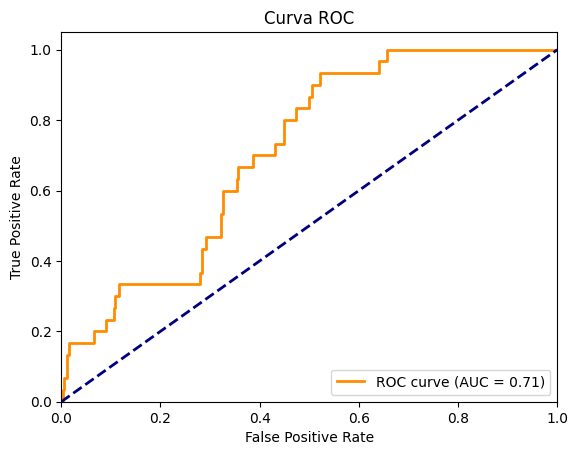

In [46]:
# Obtener probabilidades de clase positiva
y_scores = best_model.predict_proba(X_test_scaled)[:, 1]

# Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

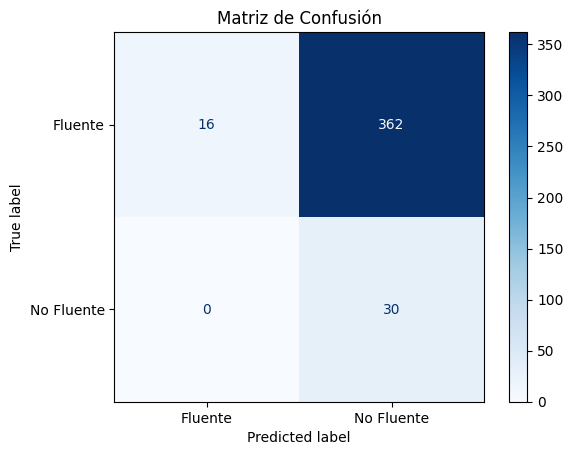

In [47]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_decoded, labels=y_test.unique())

# Graficar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

In [48]:
# Importancia de características del Random Forest
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Graficar la importancia de características
plt.figure(figsize=(10, 6))
plt.title("Importancia de Características")
plt.bar(range(20), importances[indices[:20]], align="center")
plt.xticks(range(20), [X.columns[i] for i in indices[:10]], rotation=45, ha="right")
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'

In [ ]:
# df_results.to_csv("resultados_clasificacion.csv", index=False)

ExplanationDashboard solo muestra explicabilidad (SHAP)

In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

explainer = TabularExplainer(
    best_model,
    X_train_scaled,  # Datos de entrenamiento
    features=list(X_train.columns),  # Nombres de características
    classes=label_encoder.classes_  # Clases de salida
)

explanation = explainer.explain_global(X_test_scaled)
ExplanationDashboard(explanation, best_model, dataset=X_test_scaled, true_y=y_test_encoded)

ResponsibleAIDashboard muestra explicabilidad + errores + fairness.

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df["y"] = y_train_encoded
X_test_scaled_df["y"] = y_test_encoded

rai_insights = RAIInsights(
    model=best_model,
    train=X_train_scaled_df,
    test=X_test_scaled_df,
    target_column="y",
    task_type="classification",
    categorical_features=[]
)

rai_insights.compute()
ResponsibleAIDashboard(rai_insights)